In [69]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
import pandas as pd
import numpy as np
train = pd.read_csv("train_data.csv")
train

,Atmospheric Density,Surface Temperature,Gravity,Water Content,Mineral Abundance,Orbital Period,Proximity to Star,Magnetic Field Strength,Radiation Levels,Atmospheric Composition Index,Prediction
0,0.472806,NaN,-0.313872,-2.089299,-0.152201,-0.885649,0.900105,NaN,Category_6,0.692907,5.0
1,4.180154,-1.157515,2.430956,-1.595850,-3.188678,-0.609434,-0.199828,Category_9,Category_9,NaN,0.0
2,-0.129008,1.621592,-0.785741,2.081196,-1.413796,-0.095152,-3.502577,NaN,Category_8,-0.677182,4.0
3,-3.122000,-2.299818,1.072092,0.353524,-0.192529,2.917067,-1.972329,NaN,Category_11,0.109429,1.0
4,-1.459426,2.890268,0.148757,-0.804439,0.494875,0.044910,-0.438796,Category_6,Category_10,0.407941,9.0
...,...,...,...,...,...,...,...,...,...,...,...
59995,-0.316003,-1.160519,0.544548,-1.407123,1.427861,0.849849,-1.932329,Category_8,Category_5,1.333760,8.0
59996,0.789506,-2.645345,-0.375569,-2.579966,0.783195,0.671547,-2.041189,Category_14,Category_4,0.170505,3.0
59997,-0.662563,0.642230,-1.175106,-2.783240,-0.902704,-1.694373,-1.824274,Category_8,Category_8,1.010311,5.0
59998,0.475118,-0.021458,2.086274,1.444825,-1.986595,-2.113147,-0.348915,Category_11,Category_9,-0.665345,6.0


In [71]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


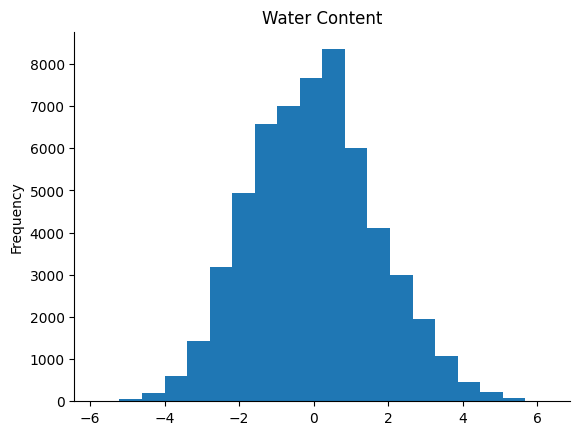

In [3]:
from matplotlib import pyplot as plt
train['Water Content'].plot(kind='hist', bins=20, title='Water Content')
plt.gca().spines[['top', 'right',]].set_visible(False)

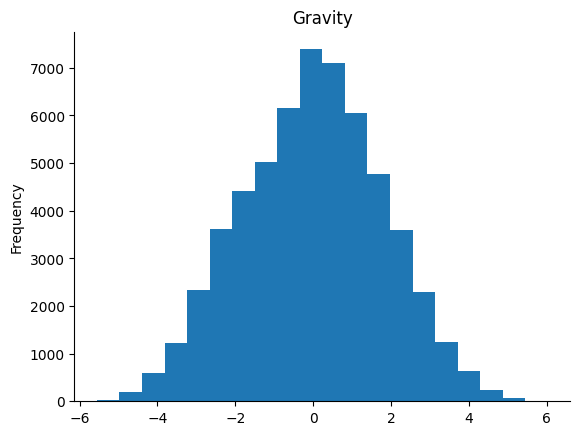

In [4]:
from matplotlib import pyplot as plt
train['Gravity'].plot(kind='hist', bins=20, title='Gravity')
plt.gca().spines[['top', 'right',]].set_visible(False)

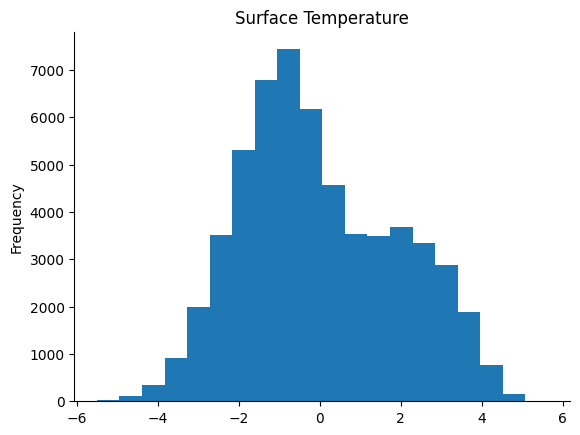

In [5]:
from matplotlib import pyplot as plt
train['Surface Temperature'].plot(kind='hist', bins=20, title='Surface Temperature')
plt.gca().spines[['top', 'right',]].set_visible(False)

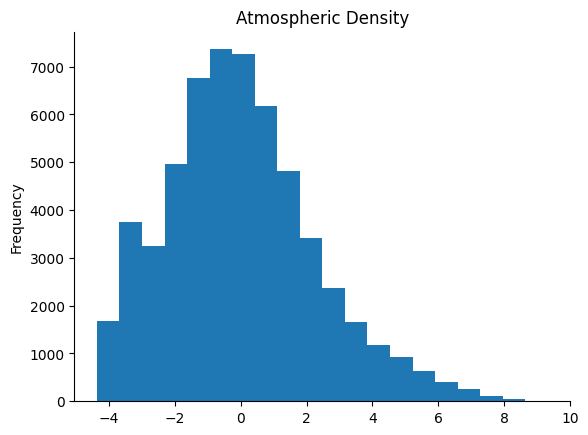

In [6]:
from matplotlib import pyplot as plt
train['Atmospheric Density'].plot(kind='hist', bins=20, title='Atmospheric Density')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [7]:
train.isnull().sum()

Atmospheric Density              2984
Surface Temperature              3032
Gravity                          2984
Water Content                    3077
Mineral Abundance                2921
Orbital Period                   2997
Proximity to Star                2945
Magnetic Field Strength          3058
Radiation Levels                 3021
Atmospheric Composition Index    2942
Prediction                       3039
dtype: int64

In [8]:
columns =['Atmospheric Density',
'Gravity',
'Water Content',
'Mineral Abundance',
'Orbital Period',
'Proximity to Star',
'Atmospheric Composition Index',
'Prediction']

In [9]:
train = pd.get_dummies(train, columns=["Magnetic Field Strength", "Radiation Levels"])


In [10]:
train["Water Content"] = train["Water Content"].apply(lambda x: max(x, 0))
train["Mineral Abundance"] = train["Mineral Abundance"].apply(lambda x: max(x, 0))



In [11]:
for col in ["Atmospheric Density", "Gravity"]:
    median_value = train[train[col] > 0][col].median()  # Get median of positive values
    train[col] = train[col].apply(lambda x: median_value if x < 0 else x)

In [12]:
columns_to_fix = ["Surface Temperature", "Orbital Period", "Proximity to Star"]

# Convert negative values to positive
train[columns_to_fix] = train[columns_to_fix].abs()

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10),
    max_iter=5,
    random_state=42
)
train[columns] = imputer.fit_transform(train[columns])

In [83]:
train = train.apply(pd.to_numeric, errors='coerce')  # Convert all columns to numeric
negative_counts = (train < 0).sum()
print("Negative Value Counts:\n", negative_counts[negative_counts > 0])


Negative Value Counts:
 Atmospheric Composition Index    28850
dtype: int64


In [84]:
train

,Atmospheric Density,Surface Temperature,Gravity,Water Content,Mineral Abundance,Orbital Period,Proximity to Star,Atmospheric Composition Index,Prediction,Magnetic Field Strength_Category_1,...,Radiation Levels_Category_19,Radiation Levels_Category_2,Radiation Levels_Category_20,Radiation Levels_Category_3,Radiation Levels_Category_4,Radiation Levels_Category_5,Radiation Levels_Category_6,Radiation Levels_Category_7,Radiation Levels_Category_8,Radiation Levels_Category_9
0,0.472806,NaN,1.225850,0.000000,0.000000,0.885649,0.900105,0.692907,5.0,False,...,False,False,False,False,False,False,True,False,False,False
1,4.180154,1.157515,2.430956,0.000000,0.000000,0.609434,0.199828,0.976931,0.0,False,...,False,False,False,False,False,False,False,False,False,True
2,1.443079,1.621592,1.225850,2.081196,0.000000,0.095152,3.502577,-0.677182,4.0,False,...,False,False,False,False,False,False,False,False,True,False
3,1.443079,2.299818,1.072092,0.353524,0.000000,2.917067,1.972329,0.109429,1.0,False,...,False,False,False,False,False,False,False,False,False,False
4,1.443079,2.890268,0.148757,0.000000,0.494875,0.044910,0.438796,0.407941,9.0,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,1.443079,1.160519,0.544548,0.000000,1.427861,0.849849,1.932329,1.333760,8.0,False,...,False,False,False,False,False,True,False,False,False,False
59996,0.789506,2.645345,1.225850,0.000000,0.783195,0.671547,2.041189,0.170505,3.0,False,...,False,False,False,False,True,False,False,False,False,False
59997,1.443079,0.642230,1.225850,0.000000,0.000000,1.694373,1.824274,1.010311,5.0,False,...,False,False,False,False,False,False,False,False,True,False
59998,0.475118,0.021458,2.086274,1.444825,0.000000,2.113147,0.348915,-0.665345,6.0,False,...,False,False,False,False,False,False,False,False,False,True


In [85]:
import pandas as pd
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()

for col in numeric_cols:
    non_null_mask = ~train[col].isna()
    non_null_data = train.loc[non_null_mask, col].values.reshape(-1, 1)

    transformer = PowerTransformer(method='yeo-johnson')
    transformed_values = transformer.fit_transform(non_null_data).flatten()

    train[f"{col}_power"] = train[col].copy()
    train.loc[non_null_mask, f"{col}_power"] = transformed_values

    print(f"Lambda for {col}: {transformer.lambdas_[0]:.4f}")

Lambda for Atmospheric Density: -0.2928
Lambda for Surface Temperature: 0.1755
Lambda for Gravity: -0.0356
Lambda for Water Content: -1.5711
Lambda for Mineral Abundance: -1.5023
Lambda for Orbital Period: -0.1244
Lambda for Proximity to Star: -0.2138
Lambda for Atmospheric Composition Index: 1.1279
Lambda for Prediction: 0.7038


In [86]:


import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


X = train.drop(columns=['Prediction'])
y = train['Prediction']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")





Accuracy: 0.9479


In [87]:
test=pd.read_csv('C:\Users\arjun\Downloads\cosmic_test.csv')
test

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (4158152022.py, line 1)

In [ ]:
test.isnull().sum()